# Mendeley datasets download via API

Get your Mendeley API token by registering an app here:

https://dev.mendeley.com/myapps.html

## Environment setup

In [4]:
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import random
from IPython.display import clear_output

ROOT = ".." # Adjust to repository root
import json
JSON_DIR = os.path.join(ROOT, "json")

from dotenv import load_dotenv
DOTENV_PATH = os.path.join(ROOT,"../../apis/.env") # Adjust to .env file location

if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    masked_parts = 2
    masked = '\\'.join(['***'] * masked_parts + abs_path.split('\\')[masked_parts:])
    print(f"Loaded .env from {masked}")
else:
    print("Failed to load .env file.")

CLIENT_ID = os.getenv("MENDELEY_CLIENT_ID")
CLIENT_SECRET = os.getenv("MENDELEY_CLIENT_SECRET")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"CLIENT_SECRET: {mask_token(CLIENT_SECRET)}")

Loaded .env from ***\***\.env
CLIENT_SECRET: hF8**********r63


## Worldwide Electricity Load Dataset

Ullah, Md Habib; Reza, Sayed Mohsin; Khan, Abdullah Al Ahad; Salekin, Siraj Us; Al-Bayati, Ali M. S.; Babaiahgari, Bhanu; Romero, David González; Molina, Jesús Rodríguez (2026), “Worldwide Electricity Load Dataset ”, Mendeley Data, V1, doi: 10.17632/ybggkc58fz.1

https://data.mendeley.com/datasets/ybggkc58fz/1

In [5]:
DATASET_ID = "ybggkc58fz"
DATASET_VERSION = "1"

TOKEN_URL = "https://api.mendeley.com/oauth/token"
DATASET_URL = f"https://api.mendeley.com/datasets/{DATASET_ID}"

# obtain access token
token_resp = requests.post(
    TOKEN_URL,
    data={"grant_type": "client_credentials", "scope": "all"},
    auth=HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET),
)
token_resp.raise_for_status()
access_token = token_resp.json()["access_token"]

# access dataset metadata
headers = {
    "Authorization": f"Bearer {access_token}",
    "Accept": "application/vnd.mendeley-public-dataset.1+json",
}
params = {"version": DATASET_VERSION}

dataset_resp = requests.get(DATASET_URL, headers=headers, params=params)
dataset_resp.raise_for_status()

print(dataset_resp.json()["name"], '\n')
print(textwrap.fill(dataset_resp.json()["description"], width=120))

weld_data = dataset_resp.json()

print("\nNumber_of_files:", len(weld_data.get("files", [])), "\n")

weld_files = weld_data.get("files", [])
preview_names = ", ".join(file["filename"] for file in weld_files[:26]) + "..."
print(textwrap.fill(preview_names, width=120))

Worldwide Electricity Load Dataset  

This dataset provides a comprehensive, global-scale collection of time-series electricity load data aggregated from
major power markets across Asia, Europe, North America, and Oceania. It captures system-level demand profiles at
consistent temporal resolution, enabling detailed analysis of consumption patterns, peak-demand behavior, and seasonal
variability across regions. The dataset is structured in a standardized and harmonized format to support load
forecasting, cross-market comparative studies, and data-driven research in power system planning, operation, and energy
market analytics.

Number_of_files: 489 

Additional_Information.csv, Australia_AEMO_2006.csv, Australia_AEMO_2007.csv, Australia_AEMO_2008.csv,
Australia_AEMO_2009.csv, Australia_AEMO_2010.csv, Australia_AEMO_2011.csv, Australia_AEMO_2012.csv,
Australia_AEMO_2013.csv, Australia_AEMO_2014.csv, Australia_AEMO_2015.csv, Australia_AEMO_2016.csv,
Australia_AEMO_2017.csv, Australia_AEMO

Save the dataset index

In [6]:
out_path = os.path.join(JSON_DIR, "worldwide-electricity-load-dataset.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(weld_files, f, ensure_ascii=False, indent=2)
print(f"Saved {len(weld_files)} entries to {out_path}")

Saved 489 entries to ..\json\worldwide-electricity-load-dataset.json


### Load the dataset index

In [7]:
read_path = os.path.join(JSON_DIR, "worldwide-electricity-load-dataset.json")
with open(read_path, "r", encoding="utf-8") as fh:
    weld_files = json.load(fh)

print(f"Loaded {len(weld_files)} entries from {read_path}")

Loaded 489 entries from ..\json\worldwide-electricity-load-dataset.json


### Explore the dataset

Exploring file contents (run this cell multiple times to explore files at random):

In [8]:
random_file = weld_files[random.randint(1, len(weld_files)-1)]
print("\nRandom file preview:", random_file["filename"])
content = random_file.get("content_details", {})
download_url = content.get("download_url")
print("Download URL:", download_url)

r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))


Random file preview: Serbia_ENTSO-E_2017.csv
Download URL: https://data.mendeley.com/public-files/datasets/ybggkc58fz/files/d0376543-16f2-4bf1-b271-e7c14149e4f8/file_downloaded
Response status code: 200


,Timestamp,Serbia
0,2017-01-01T00:00:00,5762.0
1,2017-01-01T01:00:00,5775.0
2,2017-01-01T02:00:00,5409.0
3,2017-01-01T03:00:00,5080.0
4,2017-01-01T04:00:00,4844.0


...


,Timestamp,Serbia
8756,2017-12-31T19:00:00,6004.0
8757,2017-12-31T20:00:00,5614.0
8758,2017-12-31T21:00:00,5223.0
8759,2017-12-31T22:00:00,5098.0
8760,2017-12-31T23:00:00,5096.0


Retrieving a specific file (source + year):

In [9]:
source = "Spain_ENTSO-E" # Examples: Germany_ENTSO-E, USA_ERCOT, Japan_JapanesePower, CANADA_IESO...
year = 2022
filename = f"{source}_{year}.csv"
entry = next(item for item in weld_files if item["filename"] == filename)
download_url = entry["content_details"]["download_url"]
print(filename)
r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))

Spain_ENTSO-E_2022.csv
Response status code: 200


,Timestamp,Spain
0,2022-01-01T00:00:00,21517.0
1,2022-01-01T01:00:00,20827.0
2,2022-01-01T02:00:00,19530.0
3,2022-01-01T03:00:00,18383.0
4,2022-01-01T04:00:00,17680.0


...


,Timestamp,Spain
24809,2022-12-31T22:45:00,21592.0
24810,2022-12-31T23:00:00,21236.0
24811,2022-12-31T23:15:00,20908.0
24812,2022-12-31T23:30:00,20700.0
24813,2022-12-31T23:45:00,20356.0


### Downloading the full dataset via Mendeley API

In [10]:
DATASET_DIR = os.path.join(ROOT, "datasets", "weld")
PKL_DIR = os.path.join(ROOT, "pkl", "weld")
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(ROOT, "datasets", "weld", "logs", f"{timestamp}_download_errors.log")

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(PKL_DIR, exist_ok=True)

In [11]:
results = []

weld_files = weld_data.get("files", [])

for f in weld_files:
    file_name = f.get("filename")
    content = f.get("content_details", {})

    if not file_name or content.get("content_type") != "text/csv":
        continue

    file_path = os.path.join(DATASET_DIR, file_name)
    pickle_file = os.path.join(PKL_DIR, file_name.replace(".csv", ".pkl"))

    try:
        # skip download if CSV already exists
        if not os.path.exists(file_path):
            download_url = content.get("download_url")
            if not download_url:
                continue

            r = requests.get(download_url, stream=True, timeout=10)
            r.raise_for_status()

            with open(file_path, "wb") as fh:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        fh.write(chunk)

        df = pd.read_csv(file_path)
        record_count = len(df)

        results.append({"csv_name": file_name, "record_count": record_count})
        print(f"Processed {file_name} with {record_count} records.")
        clear_output(wait=True)

        if "Timestamp" in df.columns:
            df["Timestamp"] = pd.to_datetime(df["Timestamp"])

        os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
        df.to_pickle(pickle_file)

    except Exception as e:
        with open(LOG_PATH, "a", encoding="utf-8") as log:
            log.write(f"{file_name} | {type(e).__name__} | {e}\n")
        continue

csvs_df = pd.DataFrame(results)
csvs_df["pkl_name"] = csvs_df["csv_name"].str.replace(".csv", ".pkl")

display(csvs_df)

list_file_name = "0_weld_files_list.pkl"
csvs_df.to_pickle(os.path.join(PKL_DIR, list_file_name))
print(f"Saved file list to {os.path.join(PKL_DIR, list_file_name)}")

,csv_name,record_count,pkl_name
0,Additional_Information.csv,42,Additional_Information.pkl
1,Australia_AEMO_2006.csv,17519,Australia_AEMO_2006.pkl
2,Australia_AEMO_2007.csv,17520,Australia_AEMO_2007.pkl
3,Australia_AEMO_2008.csv,17568,Australia_AEMO_2008.pkl
4,Australia_AEMO_2009.csv,17520,Australia_AEMO_2009.pkl
...,...,...,...
484,USA_SPP_2021.csv,8758,USA_SPP_2021.pkl
485,USA_SPP_2022.csv,8749,USA_SPP_2022.pkl
486,USA_SPP_2023.csv,8757,USA_SPP_2023.pkl
487,USA_SPP_2024.csv,8782,USA_SPP_2024.pkl


Saved file list to ..\pkl\weld\0_weld_files_list.pkl


## Global Day-Ahead Electricity Price Dataset

Ullah, Md Habib; Reza, Sayed Mohsin; Gundapaneni, Lasya Madhuri; Balachander, Pranav; Babaiahgari, Bhanu; Khan, Abdullah Al Ahad (2025), “Global Day-Ahead Electricity Price Dataset”, Mendeley Data, V3, doi: 10.17632/s54n4tyyz4.3
https://data.mendeley.com/datasets/s54n4tyyz4/3

In [12]:
DATASET_ID = "s54n4tyyz4"
DATASET_VERSION = "3"

TOKEN_URL = "https://api.mendeley.com/oauth/token"
DATASET_URL = f"https://api.mendeley.com/datasets/{DATASET_ID}"

# obtain access token
token_resp = requests.post(
    TOKEN_URL,
    data={"grant_type": "client_credentials", "scope": "all"},
    auth=HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET),
)
token_resp.raise_for_status()
access_token = token_resp.json()["access_token"]

# access dataset metadata
headers = {
    "Authorization": f"Bearer {access_token}",
    "Accept": "application/vnd.mendeley-public-dataset.1+json",
}
params = {"version": DATASET_VERSION}

dataset_resp = requests.get(DATASET_URL, headers=headers, params=params)
dataset_resp.raise_for_status()

print(dataset_resp.json()["name"], '\n')
print(textwrap.fill(dataset_resp.json()["description"], width=120))

daep_data = dataset_resp.json()

print("\nNumber_of_files:", len(daep_data.get("files", [])), "\n")

daep_files = daep_data.get("files", [])
preview_names = ", ".join(file["filename"] for file in daep_files[:26]) + "..."
print(textwrap.fill(preview_names, width=120))

Global Day-Ahead Electricity Price Dataset 

This dataset presents a unified, cross-continental time-series day-ahead electricity prices compiled from major
wholesale markets across Asia, Europe, North America, South America, and Oceania. The dataset offers a standardized
format that supports time-series forecasting and enables robust comparative analysis across diverse global electricity
markets.

Number_of_files: 506 

Additional_Information_by_Country.csv, Australia_AEMO_2006.csv, Australia_AEMO_2007.csv, Australia_AEMO_2008.csv,
Australia_AEMO_2009.csv, Australia_AEMO_2010.csv, Australia_AEMO_2011.csv, Australia_AEMO_2012.csv,
Australia_AEMO_2013.csv, Australia_AEMO_2014.csv, Australia_AEMO_2015.csv, Australia_AEMO_2016.csv,
Australia_AEMO_2017.csv, Australia_AEMO_2018.csv, Australia_AEMO_2019.csv, Australia_AEMO_2020.csv,
Australia_AEMO_2021.csv, Australia_AEMO_2022.csv, Australia_AEMO_2023.csv, Australia_AEMO_2024.csv,
Australia_AEMO_2025.csv, Austria_ENTSO-E_2015.csv, Austria_EN

Exploring file contents (run this cell multiple times to explore files at random):

In [13]:
random_file = daep_files[random.randint(1, len(daep_files)-1)]
print("\nRandom file preview:", random_file["filename"])
content = random_file.get("content_details", {})
download_url = content.get("download_url")
print("Download URL:", download_url)

r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))


Random file preview: USA_SPP_2016.csv
Download URL: https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/9b1d9e81-6e72-4b7c-bdb2-5d1316b74289/file_downloaded
Response status code: 200


,Timestamp,SPPNORTH_HUB,SPPSOUTH_HUB
0,2016-01-01T00:00:00,16.2804,19.8854
1,2016-01-01T01:00:00,17.0256,21.4529
2,2016-01-01T02:00:00,16.2344,21.1156
3,2016-01-01T03:00:00,16.4716,19.8961
4,2016-01-01T04:00:00,17.4630,20.4833


...


,Timestamp,SPPNORTH_HUB,SPPSOUTH_HUB
8778,2016-12-31T19:00:00,33.4502,40.0416
8779,2016-12-31T20:00:00,26.2668,35.0000
8780,2016-12-31T21:00:00,25.6518,33.3785
8781,2016-12-31T22:00:00,21.7309,29.9824
8782,2016-12-31T23:00:00,21.1957,29.1088


Comparing load and price files:

In [37]:
filename = "Spain_ENTSO-E_2020.csv"
daep_file = next(item for item in daep_files if item["filename"] == filename)
print('File in DAEP dataset: ', daep_file)
weld_file = next(item for item in weld_files if item["filename"] == filename)
print('File WELD dataset: ',weld_file)

File in DAEP dataset:  {'filename': 'Spain_ENTSO-E_2020.csv', 'id': 'a87abe1c-55ef-4e75-b087-c537062e3e91', 'folder_id': 'aee82c20-3ca5-4fa0-a036-8c542a35e015', 'content_details': {'id': '96e0865a-5269-4ee5-be0c-bd3af69a0e57', 'sha256_hash': '41207bdd01726c918f26db453719207b494407b6f1aac2e7abc658d5bb79a999', 'content_type': 'text/csv', 'size': 234524, 'created_date': '2025-08-20T01:33:45.057Z', 'download_url': 'https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/a87abe1c-55ef-4e75-b087-c537062e3e91/file_downloaded', 'view_url': 'https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/a87abe1c-55ef-4e75-b087-c537062e3e91/file_viewed', 'download_expiry_time': '2126-09-09T15:13:02.800685022Z'}, 'metrics': {'downloads': 0, 'previews': 0}, 'size': 234524, 'status': 'COMPLETED'}
File WELD dataset:  {'filename': 'Spain_ENTSO-E_2020.csv', 'id': '398b70b7-a72c-4127-828d-4da1974c816a', 'folder_id': '525de365-2d46-4811-b534-eb92eda06db2', 'content_details': {'id': '78a55c98-

Download URL DAEP: https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/a87abe1c-55ef-4e75-b087-c537062e3e91/file_downloaded
Download URL WELD: https://data.mendeley.com/public-files/datasets/ybggkc58fz/files/398b70b7-a72c-4127-828d-4da1974c816a/file_downloaded
DAEP request: 200
WELD request: 200


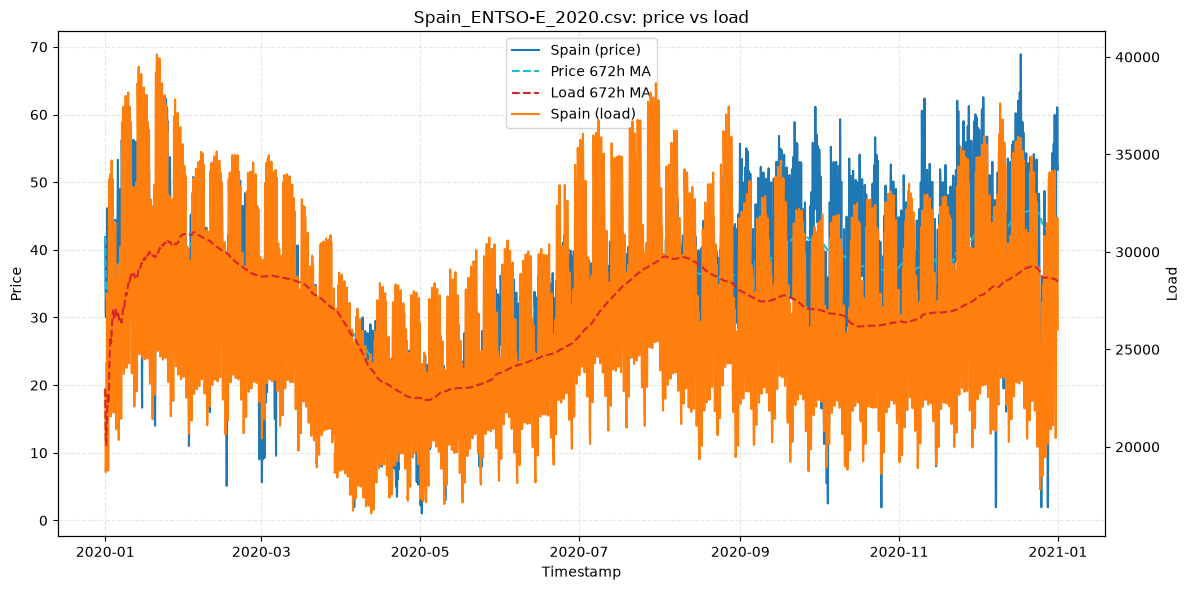

In [38]:
daep_content = daep_file.get("content_details", {})
download_url_daep = daep_content.get("download_url")

weld_content = weld_file.get("content_details", {})
download_url_weld = weld_content.get("download_url")
print("Download URL DAEP:", download_url_daep)
print("Download URL WELD:", download_url_weld)

r_daep = requests.get(download_url_daep, stream=True, timeout=10)
print("DAEP request:", r_daep.status_code)
r_weld = requests.get(download_url_weld, stream=True, timeout=10)
print("WELD request:", r_weld.status_code)

plot_df_daep = pd.read_csv(BytesIO(r_daep.content))
plot_df_daep["Timestamp"] = pd.to_datetime(plot_df_daep["Timestamp"], errors="coerce")

plot_df_weld = pd.read_csv(BytesIO(r_weld.content))
plot_df_weld["Timestamp"] = pd.to_datetime(plot_df_weld["Timestamp"], errors="coerce")

price_col = plot_df_daep.select_dtypes(include="number").columns[0]
load_col = plot_df_weld.select_dtypes(include="number").columns[0]


rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
plot_df_daep[ma_price_col] = plot_df_daep[price_col].rolling(window=rolling_window, min_periods=1).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
plot_df_weld[ma_load_col] = plot_df_weld[load_col].rolling(window=rolling_window, min_periods=1).mean()

fig, ax_price = plt.subplots(figsize=(12, 6))
line_price, = ax_price.plot(plot_df_daep["Timestamp"], plot_df_daep[price_col], color="tab:blue", label=f"{price_col} (price)")
line_price_ma, = ax_price.plot(plot_df_daep["Timestamp"], plot_df_daep[ma_price_col],
                               color="tab:cyan", linestyle="--", label=f"Price {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load, = ax_load.plot(plot_df_weld["Timestamp"], plot_df_weld[load_col], color="tab:orange", label=f"{load_col} (load)")
line_load_ma, = ax_load.plot(plot_df_weld["Timestamp"], plot_df_weld[ma_load_col],
                             color="tab:red", linestyle="--", label=f"Load {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"{filename}: price vs load")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price, line_price_ma, line_load_ma, line_load]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

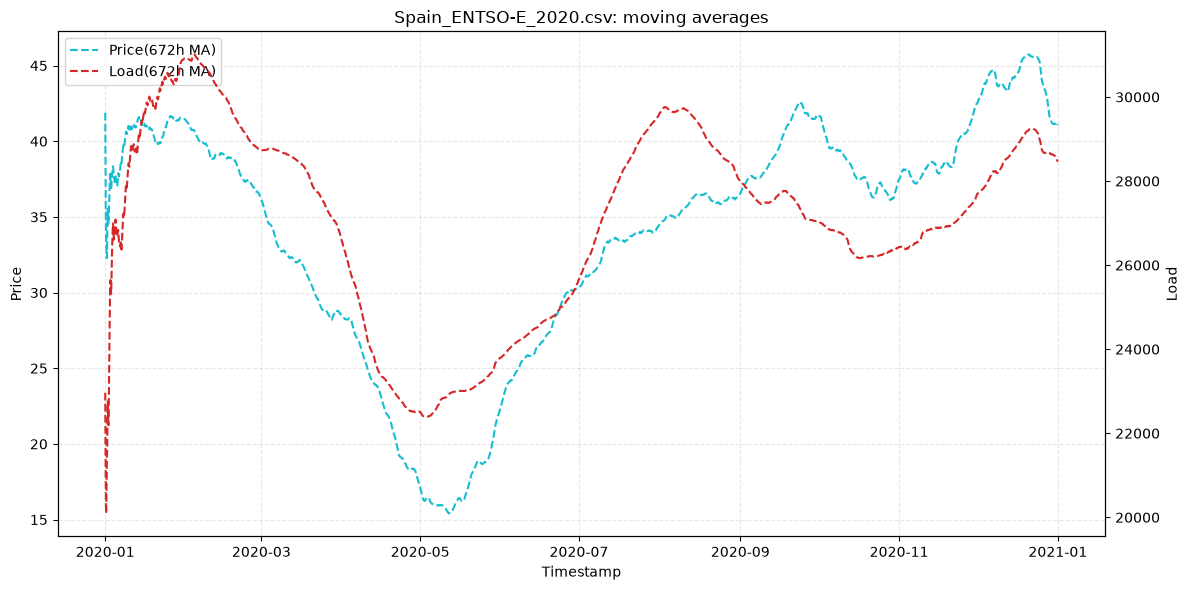

In [39]:
fig, ax_price = plt.subplots(figsize=(12, 6))

line_price_ma, = ax_price.plot(
    plot_df_daep["Timestamp"],
    plot_df_daep[ma_price_col],
    color="tab:cyan",
    linestyle="--",
    label=f"Price({rolling_window}h MA)",
)
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()

line_load_ma, = ax_load.plot(
    plot_df_weld["Timestamp"],
    plot_df_weld[ma_load_col],
    color="tab:red",
    linestyle="--",
    label=f"Load({rolling_window}h MA)",
)
ax_load.set_ylabel("Load")

ax_price.set_title(f"{filename}: moving averages")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price_ma, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

Downloading the full dataset via Mendeley API:

In [40]:
DATASET_DIR = os.path.join(ROOT, "datasets", "daep")
PKL_DIR = os.path.join(ROOT, "pkl", "daep")
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(ROOT, "datasets", "daep", "logs", f"{timestamp}_download_errors.log")

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(os.path.join(DATASET_DIR, "logs"), exist_ok=True)

In [41]:
results = []

daep_files = daep_data.get("files", [])

for f in daep_files:
    file_name = f.get("filename")
    content = f.get("content_details", {})

    if not file_name or content.get("content_type") != "text/csv":
        continue

    file_path = os.path.join(DATASET_DIR, file_name)
    pickle_file = os.path.join(PKL_DIR, file_name.replace(".csv", ".pkl"))

    try:
        # skip download if CSV already exists
        if not os.path.exists(file_path):
            download_url = content.get("download_url")
            if not download_url:
                continue

            r = requests.get(download_url, stream=True, timeout=10)
            r.raise_for_status()

            with open(file_path, "wb") as fh:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        fh.write(chunk)

        df = pd.read_csv(file_path)
        record_count = len(df)

        results.append({"csv_name": file_name, "record_count": record_count})
        print(f"Processed {file_name} with {record_count} records.")
        clear_output(wait=True)

        if "Timestamp" in df.columns:
            df["Timestamp"] = pd.to_datetime(df["Timestamp"])

        os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
        df.to_pickle(pickle_file)

    except Exception as e:
        with open(LOG_PATH, "a", encoding="utf-8") as log:
            log.write(f"{file_name} | {type(e).__name__} | {e}\n")
        continue

csvs_df = pd.DataFrame(results)
csvs_df["pkl_name"] = csvs_df["csv_name"].str.replace(".csv", ".pkl")

display(csvs_df)

list_file_name = "0_daep_files_list.pkl"
csvs_df.to_pickle(os.path.join(PKL_DIR, list_file_name))
print(f"Saved file list to {os.path.join(PKL_DIR, list_file_name)}")

,csv_name,record_count,pkl_name
0,Additional_Information_by_Country.csv,49,Additional_Information_by_Country.pkl
1,Australia_AEMO_2006.csv,17519,Australia_AEMO_2006.pkl
2,Australia_AEMO_2007.csv,17520,Australia_AEMO_2007.pkl
3,Australia_AEMO_2008.csv,17568,Australia_AEMO_2008.pkl
4,Australia_AEMO_2009.csv,17520,Australia_AEMO_2009.pkl
...,...,...,...
501,USA_SPP_2021.csv,0,USA_SPP_2021.pkl
502,USA_SPP_2022.csv,0,USA_SPP_2022.pkl
503,USA_SPP_2023.csv,0,USA_SPP_2023.pkl
504,USA_SPP_2024.csv,0,USA_SPP_2024.pkl


Saved file list to ..\pkl\daep\0_daep_files_list.pkl
